Loading data...
Clustering SM  jets (50,000 events)...
Clustering BSM jets (10,000 events)...

JET STATISTICS

  SM  QCD:
    Events clustered     : 50,000
    Total jets found     : 194,965
    Jets per event (avg) : 3.90
    Constituents/jet     : mean=40.1  median=32  std=29.4
    min=2  max=227
    <= 30  nodes : 48.4%
    <= 100 nodes : 95.4%  <- ChebNet budget
    >  100 nodes : 4.6%  (truncated to 100)

  BSM W'->XY:
    Events clustered     : 10,000
    Total jets found     : 32,007
    Jets per event (avg) : 3.20
    Constituents/jet     : mean=37.7  median=33  std=24.5
    min=2  max=207
    <= 30  nodes : 45.8%
    <= 100 nodes : 98.0%  <- ChebNet budget
    >  100 nodes : 2.0%  (truncated to 100)

  Saved → lhco_jet_graphs.png


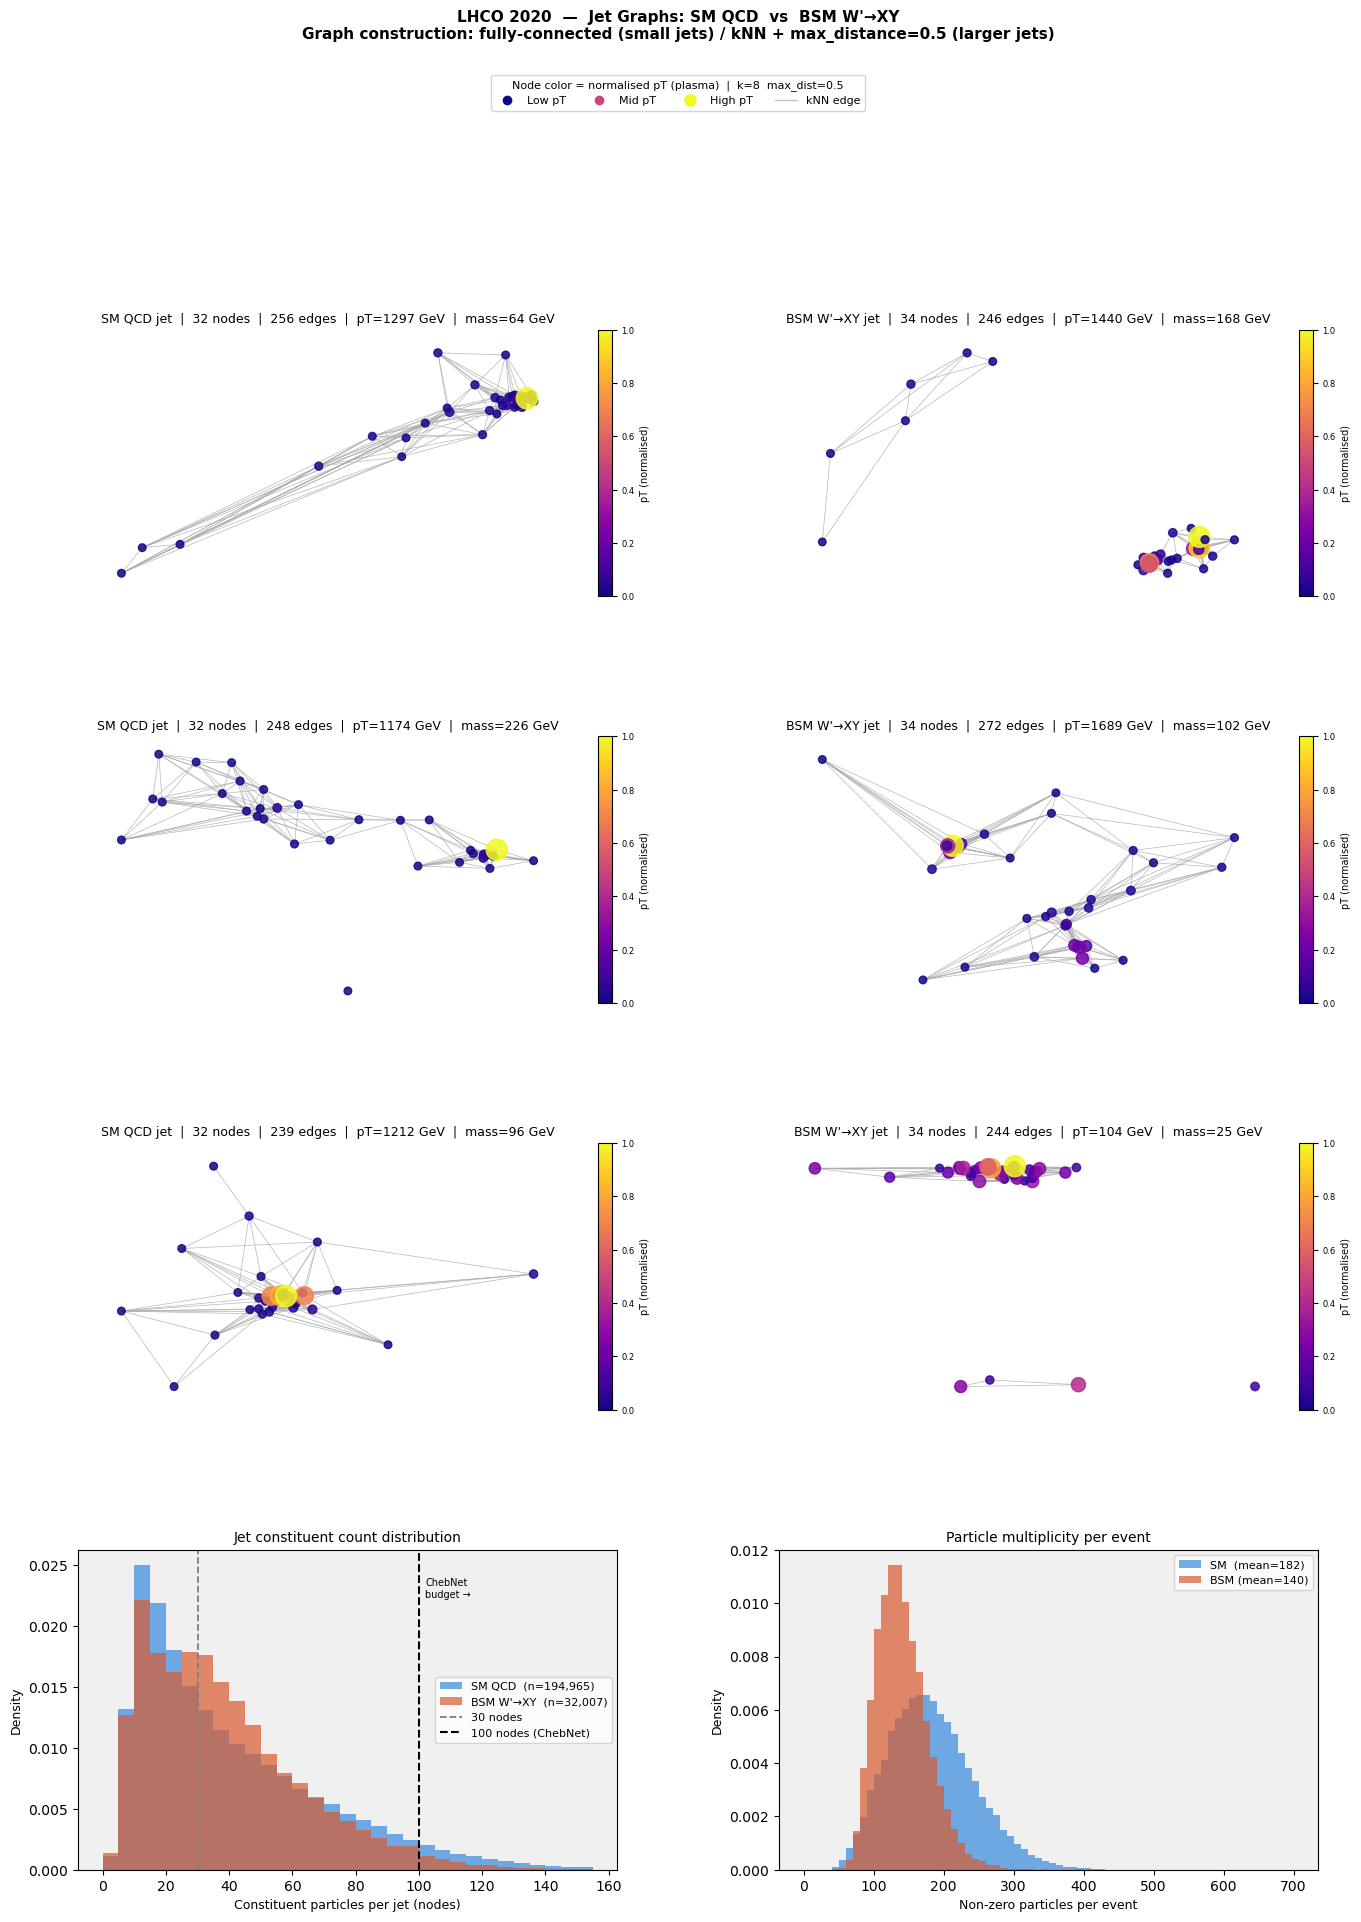

In [ ]:
"""
LHCO 2020 - Jet Graph Visualization
Graph construction approach:
  - Small point clouds (nodes <= k+1): connect everything (fully connected)
  - Larger jets: kNN with max_distance threshold
  - Visualization: PyG Data -> networkx via to_networkx, nx.draw with eta-phi positions
"""

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from matplotlib.lines import Line2D
import networkx as nx
import torch
import warnings
warnings.filterwarnings("ignore")

from torch_geometric.data import Data
from torch_geometric.utils import to_networkx

try:
    from pyjet import cluster
    HAS_PYJET = True
except ImportError:
    raise ImportError("pyjet is required: pip install pyjet")


# =============================================================================
# LOAD DATA  (SM from start, BSM from end)
# =============================================================================

def load_both_classes(path, n_sm=50000, n_bsm=10000):
    store = pd.HDFStore(path, mode="r")
    df_sm  = store.select("df", start=0,       stop=n_sm)
    df_bsm = store.select("df", start=1000000, stop=1000000 + n_bsm)
    store.close()

    def to_arrays(df):
        d = df.values.astype(np.float32)
        parts  = d[:, :2100].reshape(-1, 700, 3)
        labels = d[:, 2100].astype(int)
        return parts, labels

    p_sm,  l_sm  = to_arrays(df_sm)
    p_bsm, l_bsm = to_arrays(df_bsm)
    return p_sm, l_sm, p_bsm, l_bsm


# =============================================================================
# JET CLUSTERING
# =============================================================================

def get_jets(particles, labels, ptmin=20.0, R=1.0, max_events=None):
    jets_out = []
    n = len(particles) if max_events is None else min(max_events, len(particles))

    for i in range(n):
        pt  = particles[i, :, 0]
        eta = particles[i, :, 1]
        phi = particles[i, :, 2]
        mask = pt > 0
        if mask.sum() < 2:
            continue

        pj = np.zeros(mask.sum(),
                      dtype=[("pT","f8"),("eta","f8"),("phi","f8"),("mass","f8")])
        pj["pT"]   = pt[mask]
        pj["eta"]  = eta[mask]
        pj["phi"]  = phi[mask]

        seq  = cluster(pj, R=R, p=-1)
        jets = seq.inclusive_jets(ptmin=ptmin)

        for j in jets:
            c = j.constituents()
            if len(c) < 2:
                continue
            jets_out.append({
                "label"     : labels[i],
                "event_idx" : i,
                "jet_pt"    : j.pt,
                "jet_eta"   : j.eta,
                "jet_mass"  : j.mass,
                "n_nodes"   : len(c),
                "pt"        : np.array([p.pt  for p in c]),
                "eta"       : np.array([p.eta for p in c]),
                "phi"       : np.array([p.phi for p in c]),
            })

    return jets_out


# =============================================================================
# CREATE GRAPH FROM POINT CLOUD  
# =============================================================================

def create_graph_from_point_cloud(point_cloud, k_nearest=5, max_distance=2.0):
    """
    Create a PyG Data object from a jet point cloud.

    Args:
        point_cloud  : dict with 'coordinates' (N,2) eta-phi
                       and 'features' (N,3) pT-eta-phi
        k_nearest    : number of nearest neighbours to connect
        max_distance : max eta-phi distance for edge creation

    Returns:
        PyTorch Geometric Data object
    """
    coordinates = point_cloud['coordinates']   
    features    = point_cloud['features']     
    num_points  = coordinates.shape[0]

    if num_points <= k_nearest + 1:
        edges = []
        for i in range(num_points):
            for j in range(num_points):
                if i != j:
                    edges.append([i, j])

        if len(edges) == 0:          
            edges = [[0, 0]]

        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

    else:
        edges = []
        for i in range(num_points):
            point     = coordinates[i]
            distances = np.sqrt(np.sum((coordinates - point) ** 2, axis=1))

            # k nearest neighbours excluding self
            nearest_indices = np.argsort(distances)[1:k_nearest + 1]

            for j in nearest_indices:
                if distances[j] < max_distance:   # distance gate
                    edges.append([i, int(j)])

        if len(edges) == 0:          #
            edges = [[0, 1], [1, 0]]

        edge_index = torch.tensor(edges, dtype=torch.long).t().contiguous()

    x    = torch.tensor(features, dtype=torch.float)
    data = Data(x=x, edge_index=edge_index)
    return data


def jet_to_pyg(jet, k_nearest=5, max_distance=2.0, max_nodes=100):
    """Convert a clustered jet dict into a PyG Data object."""
    pt  = jet["pt"]
    eta = jet["eta"]
    phi = jet["phi"]

    # truncate to max_nodes by pT rank
    if len(pt) > max_nodes:
        order = np.argsort(pt)[::-1][:max_nodes]
        pt, eta, phi = pt[order], eta[order], phi[order]

    # normalise pT per jet for features
    pt_norm = pt / (pt.max() + 1e-9)

    point_cloud = {
        "coordinates": np.stack([eta, phi], axis=1).astype(np.float32),
        "features"   : np.stack([pt_norm, eta, phi], axis=1).astype(np.float32),
    }
    return create_graph_from_point_cloud(point_cloud,
                                         k_nearest=k_nearest,
                                         max_distance=max_distance)


# =============================================================================
# VISUALIZE GRAPH  
# =============================================================================

def visualize_graph(graph_data, jet, ax, title):
    """
    Visualize a PyG Data object using to_networkx + nx.draw.
    Node positions = (eta, phi) from features[:,1:3].
    Node color     = normalised pT (features[:,0]).
    """
    G   = to_networkx(graph_data, to_undirected=True)

    pos = {i: (graph_data.x[i, 1].item(),
               graph_data.x[i, 2].item())
           for i in range(graph_data.x.size(0))}

    node_colors = graph_data.x[:, 0].numpy()


    pt_raw  = jet["pt"]
    if len(pt_raw) > graph_data.x.size(0):
        pt_raw = np.sort(pt_raw)[::-1][:graph_data.x.size(0)]
    pt_norm_size = (pt_raw - pt_raw.min()) / (pt_raw.max() - pt_raw.min() + 1e-9)
    node_sizes   = 30 + 200 * pt_norm_size

    ax.set_facecolor("#1a1a2e")

    nx.draw(G, pos,
            ax=ax,
            node_size=node_sizes,
            node_color=node_colors,
            cmap=plt.cm.plasma,
            vmin=0.0, vmax=1.0,
            with_labels=False,
            width=0.5,
            alpha=0.85,
            edge_color="#aaaaaa")

    ax.set_title(title, fontsize=9, pad=5)
    ax.set_xlabel("η", fontsize=8)
    ax.set_ylabel("φ", fontsize=8)

    # colorbar
    sm_cb = plt.cm.ScalarMappable(cmap=plt.cm.plasma,
                                   norm=plt.Normalize(vmin=0, vmax=1))
    sm_cb.set_array([])
    cb = plt.colorbar(sm_cb, ax=ax, fraction=0.035, pad=0.04)
    cb.set_label("pT (normalised)", fontsize=7)
    cb.ax.tick_params(labelsize=6)


# =============================================================================
# PRINT STATISTICS
# =============================================================================

def print_stats(jets_sm, jets_bsm, n_events_sm, n_events_bsm):
    print("\n" + "=" * 60)
    print("JET STATISTICS")
    print("=" * 60)

    for jets, name, n_ev in [(jets_sm,  "SM  QCD",    n_events_sm),
                              (jets_bsm, "BSM W'->XY", n_events_bsm)]:
        counts = np.array([j["n_nodes"] for j in jets])
        n_jets = len(jets)
        print(f"\n  {name}:")
        print(f"    Events clustered     : {n_ev:,}")
        print(f"    Total jets found     : {n_jets:,}")
        print(f"    Jets per event (avg) : {n_jets / n_ev:.2f}")
        print(f"    Constituents/jet     : mean={counts.mean():.1f}  "
              f"median={np.median(counts):.0f}  std={counts.std():.1f}")
        print(f"    min={counts.min()}  max={counts.max()}")
        print(f"    <= 30  nodes : {(counts<=30).mean()*100:.1f}%")
        print(f"    <= 100 nodes : {(counts<=100).mean()*100:.1f}%  <- ChebNet budget")
        print(f"    >  100 nodes : {(counts>100).mean()*100:.1f}%  (truncated to 100)")


# =============================================================================
# MAIN VISUALIZATION
# =============================================================================

def visualize(path,
              n_sm=50000, n_bsm=10000,
              n_pairs=3, k_nearest=5, max_distance=2.0, max_nodes=100,
              ptmin=20.0):

    # ── Load ──────────────────────────────────────────────────────────────────
    print("Loading data...")
    p_sm, l_sm, p_bsm, l_bsm = load_both_classes(path, n_sm=n_sm, n_bsm=n_bsm)

    # ── Cluster ───────────────────────────────────────────────────────────────
    print(f"Clustering SM  jets ({n_sm:,} events)...")
    jets_sm  = get_jets(p_sm,  l_sm,  ptmin=ptmin)

    print(f"Clustering BSM jets ({n_bsm:,} events)...")
    jets_bsm = get_jets(p_bsm, l_bsm, ptmin=ptmin)

    # ── Print stats ───────────────────────────────────────────────────────────
    print_stats(jets_sm, jets_bsm, n_sm, n_bsm)

    # ── Pick representative jets ──────────────────────────────────────────────
    def pick_jets(jets, n=3, target_nodes=32):
        sorted_jets = sorted(jets, key=lambda j: abs(j["n_nodes"] - target_nodes))
        seen, picked = set(), []
        for j in sorted_jets:
            if j["event_idx"] not in seen:
                picked.append(j)
                seen.add(j["event_idx"])
            if len(picked) == n:
                break
        return picked

    sample_sm  = pick_jets(jets_sm,  n=n_pairs, target_nodes=32)
    sample_bsm = pick_jets(jets_bsm, n=n_pairs, target_nodes=34)

    # ── Histogram data ────────────────────────────────────────────────────────
    counts_sm  = np.array([j["n_nodes"] for j in jets_sm])
    counts_bsm = np.array([j["n_nodes"] for j in jets_bsm])
    n_real_sm  = (p_sm[:, :, 0]  > 0).sum(axis=1)
    n_real_bsm = (p_bsm[:, :, 0] > 0).sum(axis=1)

    # ── Figure layout ─────────────────────────────────────────────────────────
    total_rows = n_pairs + 1
    fig = plt.figure(figsize=(16, 5 * n_pairs + 5))
    fig.patch.set_facecolor("#f7f7f7")
    gs  = gridspec.GridSpec(total_rows, 2, figure=fig,
                            hspace=0.50, wspace=0.30,
                            height_ratios=[1] * n_pairs + [1.2])

    # ── Draw graph pairs ──────────────────────────────────────────────────────
    for row in range(n_pairs):
        j_sm  = sample_sm[row]
        j_bsm = sample_bsm[row]

        pyg_sm  = jet_to_pyg(j_sm,  k_nearest=k_nearest,
                              max_distance=max_distance, max_nodes=max_nodes)
        pyg_bsm = jet_to_pyg(j_bsm, k_nearest=k_nearest,
                              max_distance=max_distance, max_nodes=max_nodes)

        ax_sm  = fig.add_subplot(gs[row, 0])
        ax_bsm = fig.add_subplot(gs[row, 1])

        visualize_graph(pyg_sm,  j_sm,  ax_sm,
                        f"SM QCD jet  |  {j_sm['n_nodes']} nodes  "
                        f"|  {pyg_sm.edge_index.shape[1]} edges  "
                        f"|  pT={j_sm['jet_pt']:.0f} GeV  "
                        f"|  mass={j_sm['jet_mass']:.0f} GeV")

        visualize_graph(pyg_bsm, j_bsm, ax_bsm,
                        f"BSM W'→XY jet  |  {j_bsm['n_nodes']} nodes  "
                        f"|  {pyg_bsm.edge_index.shape[1]} edges  "
                        f"|  pT={j_bsm['jet_pt']:.0f} GeV  "
                        f"|  mass={j_bsm['jet_mass']:.0f} GeV")

    # ── Constituent count histogram ───────────────────────────────────────────
    ax_hist = fig.add_subplot(gs[n_pairs, 0])
    bins = np.arange(0, 160, 5)
    ax_hist.hist(counts_sm,  bins=bins, alpha=0.7, color="#378ADD",
                 label=f"SM QCD  (n={len(counts_sm):,})", density=True)
    ax_hist.hist(counts_bsm, bins=bins, alpha=0.7, color="#D85A30",
                 label=f"BSM W'→XY  (n={len(counts_bsm):,})", density=True)
    ax_hist.axvline(30,  color="gray",  lw=1.3, ls="--", label="30 nodes")
    ax_hist.axvline(100, color="black", lw=1.5, ls="--", label="100 nodes (ChebNet)")
    ax_hist.set_xlabel("Constituent particles per jet (nodes)", fontsize=9)
    ax_hist.set_ylabel("Density", fontsize=9)
    ax_hist.set_title("Jet constituent count distribution", fontsize=10)
    ax_hist.legend(fontsize=8)
    ax_hist.set_facecolor("#f0f0f0")
    ax_hist.text(102, ax_hist.get_ylim()[1] * 0.85,
                 "ChebNet\nbudget →", fontsize=7, color="black", ha="left")

    # ── Particle multiplicity density ─────────────────────────────────────────
    ax_mult = fig.add_subplot(gs[n_pairs, 1])
    bins2 = np.linspace(0, 700, 71)
    ax_mult.hist(n_real_sm,  bins=bins2, alpha=0.7, color="#378ADD",
                 label=f"SM  (mean={n_real_sm.mean():.0f})", density=True)
    ax_mult.hist(n_real_bsm, bins=bins2, alpha=0.7, color="#D85A30",
                 label=f"BSM (mean={n_real_bsm.mean():.0f})", density=True)
    ax_mult.set_xlabel("Non-zero particles per event", fontsize=9)
    ax_mult.set_ylabel("Density", fontsize=9)
    ax_mult.set_title("Particle multiplicity per event", fontsize=10)
    ax_mult.legend(fontsize=8)
    ax_mult.set_facecolor("#f0f0f0")

    # ── Global legend ─────────────────────────────────────────────────────────
    cmap = plt.cm.plasma
    legend_elements = [
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor=cmap(0.0), markersize=8, label='Low pT'),
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor=cmap(0.5), markersize=8, label='Mid pT'),
        Line2D([0], [0], marker='o', color='w',
               markerfacecolor=cmap(1.0), markersize=10, label='High pT'),
        Line2D([0], [0], color='#aaaaaa', lw=1, alpha=0.7, label='kNN edge'),
    ]
    fig.legend(handles=legend_elements,
               loc="upper center", ncol=4, fontsize=8, framealpha=0.8,
               title=f"Node color = normalised pT (plasma)  |  "
                     f"k={k_nearest}  max_dist={max_distance}",
               title_fontsize=8,
               bbox_to_anchor=(0.5, 1.01))

    plt.suptitle(
        "LHCO 2020  —  Jet Graphs: SM QCD  vs  BSM W'→XY\n"
        "Graph construction: fully-connected (small jets) / "
        f"kNN + max_distance={max_distance} (larger jets)",
        fontsize=11, fontweight="bold", y=1.04)

    out = "lhco_jet_graphs.png"
    plt.savefig(out, dpi=150, bbox_inches="tight",
                facecolor=fig.get_facecolor())
    print(f"\n  Saved → {out}")
    plt.show()


# =============================================================================
# CONFIG
# =============================================================================

if __name__ == "__main__":
    PATH         = "events_anomalydetection_v2.h5"
    N_SM         = 50000   # SM events to cluster
    N_BSM        = 10000   # BSM events to cluster
    N_PAIRS      = 3       # SM vs BSM graph pairs to show
    K_NEAREST    = 8       # kNN neighbours
    MAX_DISTANCE = 0.5     # max eta-phi distance for edges
    MAX_NODES    = 100     # truncate jets above this

    visualize(PATH,
              n_sm=N_SM, n_bsm=N_BSM,
              n_pairs=N_PAIRS,
              k_nearest=K_NEAREST,
              max_distance=MAX_DISTANCE,
              max_nodes=MAX_NODES)